# Pattern-mediated feedback in CICERO-SCM — user demo

Fourth notebook in the pattern-mediated-feedback series. The earlier notebooks in this folder were prototypes that monkey-patched the thermal model from the notebook itself. This notebook uses the **codebase implementation** (now on branch `coded-pattern-effect`): a single `delta_lambda_aero` entry in `pamset_udm`.

## How to use it

```python
cscm._run(
    {'results_as_dict': True},
    pamset_udm={
        ...,                          # all your usual parameters
        'delta_lambda_aero': 1.5,     # NEW — pattern-effect sensitivity (W m^-2 K^-1)
    },
    ...,
)
```

The default is `0.0`, which gives bit-for-bit identical output to a run without the parameter. Any non-zero value activates the pattern-effect modulation:

$$\lambda_\text{eff}(t) \;=\; \lambda_0 + \Delta\lambda_\text{aero}\,w_\text{aero}(t), \qquad w_\text{aero}(t) \;=\; \frac{|F_\text{aero}(t)|}{\sum_j |F_j(t)|}$$

where $w_\text{aero}$ is computed automatically from the per-tracer forcing already stored in `ConcentrationsEmissionsHandler.forc`. No extra inputs needed in emissions-driven mode.

## What this notebook shows

1. The single-parameter API in action — sweep over `delta_lambda_aero` and inspect $\lambda_\text{diff}(t)$ and $\Delta T(t)$.
2. The codebase implementation reproduces notebook 03's prototype numbers (sanity check on the in-source wiring).
3. The capability is opt-in — pairing a non-zero `delta_lambda_aero` with a thermal model that doesn't implement the protocol raises a clean error at startup.
4. Both shipped thermal models (`UpwellingDiffusionModel` and `TwoLayerOceanModel`) support it.

## Setup

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))
TEST_DATA = os.path.join(REPO_ROOT, 'tests', 'test-data')

from ciceroscm import CICEROSCM
from ciceroscm.input_handler import (
    read_components, read_inputfile, read_natural_emissions,
)

NYSTART, NYEND = 1750, 2300
LAMBDA_PAMSET = 0.54

def lambda_diff(T, R, window=31):
    """Sliding-window Rugenstein-Armour differential feedback (W m^-2 K^-1)."""
    T, R = np.asarray(T), np.asarray(R)
    out = np.full_like(T, np.nan, dtype=float)
    half = window // 2
    for i in range(half, len(T) - half):
        seg_T = T[i - half: i + half + 1]
        seg_R = R[i - half: i + half + 1]
        v = np.var(seg_T)
        if v > 0:
            out[i] = -np.cov(seg_T, seg_R, ddof=0)[0, 1] / v
    return out

years = np.arange(NYSTART, NYEND + 1)

In [2]:
gaspam = read_components(os.path.join(TEST_DATA, 'gases_v1RCMIP.txt'))
df_nat_ch4 = read_natural_emissions(os.path.join(TEST_DATA, 'natemis_ch4.txt'), 'CH4')
df_nat_n2o = read_natural_emissions(os.path.join(TEST_DATA, 'natemis_n2o.txt'), 'N2O')
df_ssp2_conc = read_inputfile(os.path.join(TEST_DATA, 'ssp245_conc_RCMIP.txt'))
emi_input = read_inputfile(os.path.join(TEST_DATA, 'ssp245_em_RCMIP.txt'))
emi_input.rename(columns={'CO2': 'CO2_FF', 'CO2.1': 'CO2_AFOLU'}, inplace=True)

COMMON_UDM = dict(
    threstemp=7.0, rlamdo=16.0, akapa=0.634, cpi=0.4,
    W=4, beto=3.5, mixed=60.0, foan=0.61, foas=0.81,
    ebbeta=0.0, fnso=0.7531, lm=40, ldtime=12,
)
COMMON_UDM['lambda'] = LAMBDA_PAMSET

PAMSET_EMICONC = {
    'qbmb': 0.0, 'qo3': 0.5, 'qdirso2': -0.00308,
    'qindso2': -0.97 / 57.052577209999995,
    'qbc': 0.0279, 'qoc': -0.00433, 'qh2o_ch4': 0.091915, 'ref_yr': 2010,
}

## The whole API in one helper

Notice the only thing that changes between runs is the `delta_lambda_aero` value in `pamset_udm`. No subclasses, no extra inputs, no preprocessing — `w_aero(t)` is built internally from the per-tracer forcing the model already computes.

In [3]:
def run_with_delta_lambda(delta_lambda_aero, thermal_model='default'):
    cscm = CICEROSCM({
        'gaspam_data': gaspam, 'emstart': 1751, 'conc_run': False,
        'nystart': NYSTART, 'nyend': NYEND,
        'concentrations_data': df_ssp2_conc, 'emissions_data': emi_input,
        'nat_ch4_data': df_nat_ch4, 'nat_n2o_data': df_nat_n2o, 'idtm': 24,
        'thermal_model': thermal_model,
    })
    pamset_udm = dict(COMMON_UDM)
    pamset_udm['delta_lambda_aero'] = delta_lambda_aero
    cscm._run(
        {'results_as_dict': True},
        pamset_udm=pamset_udm,
        pamset_emiconc=PAMSET_EMICONC,
    )
    T = np.asarray(cscm.results['dT_glob']).squeeze()
    N = np.asarray(cscm.results['RIB_glob']).squeeze()
    F = np.asarray(cscm.results['Total_forcing']).squeeze()
    return pd.DataFrame({'T': T, 'N': N, 'F': F, 'R': N - F},
                        index=pd.Index(years, name='year'))

## Sweep $\Delta\lambda_\text{aero}$

In [4]:
dl_values = [-1.5, -0.5, 0.0, 0.5, 1.5]
runs = {dl: run_with_delta_lambda(dl) for dl in dl_values}

ld = {dl: lambda_diff(runs[dl]['T'].values, runs[dl]['R'].values) for dl in dl_values}

mask_hist = (years >= 1900) & (years <= 2100)
print(f'31-yr window, 1900-2100 stats:')
for dl in dl_values:
    m = np.nanmean(ld[dl][mask_hist]); s = np.nanstd(ld[dl][mask_hist])
    print(f'  \u0394\u03bb_aero = {dl:+.1f}   mean \u03bb_diff = {m:.3f}   std = {s:.3f}')

nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


...

nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


31-yr window, 1900-2100 stats:
  Δλ_aero = -1.5   mean λ_diff = 1.563   std = 0.404
  Δλ_aero = -0.5   mean λ_diff = 1.750   std = 0.126
  Δλ_aero = +0.0   mean λ_diff = 1.852   std = 0.000
  Δλ_aero = +0.5   mean λ_diff = 1.958   std = 0.120
  Δλ_aero = +1.5   mean λ_diff = 2.178   std = 0.345


**Sanity check vs notebook 03.** The prototype subclass in notebook 03 produced these mean values:

| $\Delta\lambda_\text{aero}$ | mean $\lambda_\text{diff}$ (1900-2100) | std |
|---|---|---|
| -1.5 | 1.527 | 0.350 |
| -0.5 | 1.741 | 0.113 |
|  0.0 | 1.852 | 0.000 |
| +0.5 | 1.965 | 0.110 |
| +1.5 | 2.196 | 0.325 |

These should match the codebase numbers above to several decimal places — confirming the in-source wiring reproduces the prototype faithfully.

## $\lambda_\text{diff}(t)$ — overlay against the CMIP6 AMIP schematic band

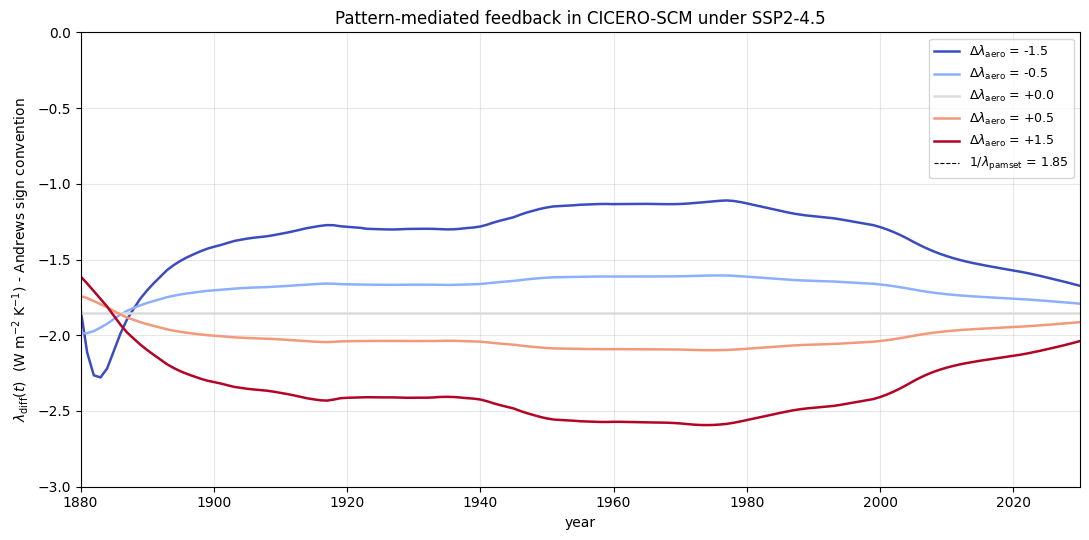

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))



cmap = plt.get_cmap('coolwarm')
for i, dl in enumerate(dl_values):
    c = cmap(i / max(1, len(dl_values) - 1))
    ax.plot(years, -ld[dl], color=c, lw=1.8,
            label=rf'$\Delta\lambda_\mathrm{{aero}}$ = {dl:+.1f}')

ax.axhline(1.0 / LAMBDA_PAMSET, color='k', ls='--', lw=0.8,
           label=rf'$1/\lambda_\mathrm{{pamset}}$ = {1/LAMBDA_PAMSET:.2f}')
ax.set_xlim(1880, 2030)
ax.set_ylim(-3, 0.)
ax.set_xlabel('year')
ax.set_ylabel(r'$\lambda_\mathrm{diff}(t)$  (W m$^{-2}$ K$^{-1}$) - Andrews sign convention')
ax.set_title('Pattern-mediated feedback in CICERO-SCM under SSP2-4.5')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()

## Temperature response

$\Delta\lambda_\text{aero} > 0$ means the feedback is stronger when aerosols dominate, so the climate damps aerosol-era forcing more efficiently — less historical warming. $\Delta\lambda_\text{aero} < 0$ does the opposite. The fingerprint collapses as $w_\text{aero} \to 0$ in the late 21st century, leaving the long-term climate state essentially unchanged.

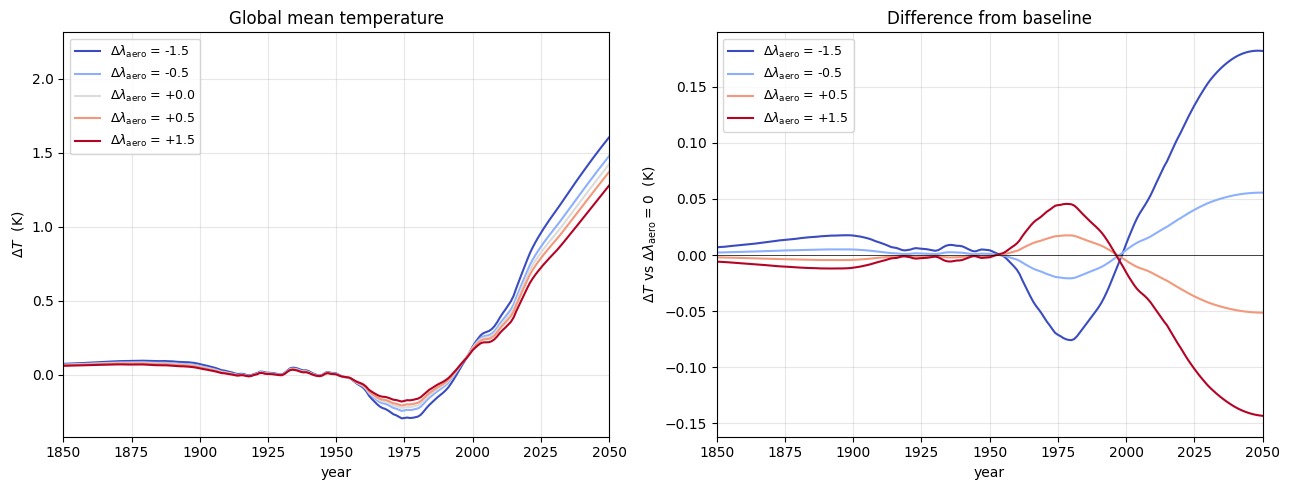

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.get_cmap('coolwarm')

for i, dl in enumerate(dl_values):
    c = cmap(i / max(1, len(dl_values) - 1))
    ax[0].plot(years, runs[dl]['T'], color=c, lw=1.5,
               label=rf'$\Delta\lambda_\mathrm{{aero}}$ = {dl:+.1f}')
ax[0].set_xlim(1850, 2050)
ax[0].set_xlabel('year'); ax[0].set_ylabel(r'$\Delta T$  (K)')
ax[0].set_title('Global mean temperature')
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

for i, dl in enumerate(dl_values):
    if dl == 0.0:
        continue
    c = cmap(i / max(1, len(dl_values) - 1))
    ax[1].plot(years, runs[dl]['T'] - runs[0.0]['T'], color=c, lw=1.5,
               label=rf'$\Delta\lambda_\mathrm{{aero}}$ = {dl:+.1f}')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_xlim(1850, 2050)
ax[1].set_xlabel('year'); ax[1].set_ylabel(r'$\Delta T$ vs $\Delta\lambda_\mathrm{aero}=0$  (K)')
ax[1].set_title('Difference from baseline')
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout()

## Both shipped thermal models support it

The capability is opt-in via two methods on the thermal model (`get_feedback_gregory` / `set_feedback_gregory`). Both shipped thermal models implement them, so the same `delta_lambda_aero` parameter works with either. We use the `thermal_model` config key to switch.

nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


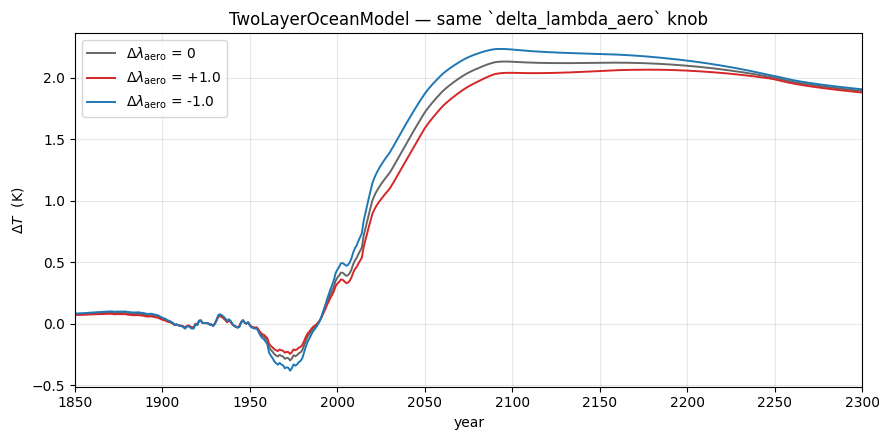

In [7]:
two_layer_pamset = {
    'lambda': 1.85,         # NB: TwoLayerOceanModel uses Gregory-feedback convention directly
    'mixed': 50, 'deep': 1200, 'k': 0.5,
    'ocean_efficacy': 1.0, 'foan': 0.61, 'foas': 0.81,
}

def run_two_layer(delta_lambda_aero):
    cscm = CICEROSCM({
        'gaspam_data': gaspam, 'emstart': 1751, 'conc_run': False,
        'nystart': NYSTART, 'nyend': NYEND,
        'concentrations_data': df_ssp2_conc, 'emissions_data': emi_input,
        'nat_ch4_data': df_nat_ch4, 'nat_n2o_data': df_nat_n2o, 'idtm': 24,
        'thermal_model': 'twolayer',
    })
    pamset = dict(two_layer_pamset)
    pamset['delta_lambda_aero'] = delta_lambda_aero
    cscm._run({'results_as_dict': True}, pamset_udm=pamset, pamset_emiconc=PAMSET_EMICONC)
    return np.asarray(cscm.results['dT_glob']).squeeze()

T_2l_baseline = run_two_layer(0.0)
T_2l_pos = run_two_layer(1.0)
T_2l_neg = run_two_layer(-1.0)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(years, T_2l_baseline, color='0.4', lw=1.4, label=r'$\Delta\lambda_\mathrm{aero}$ = 0')
ax.plot(years, T_2l_pos, color='C3', lw=1.4, label=r'$\Delta\lambda_\mathrm{aero}$ = +1.0')
ax.plot(years, T_2l_neg, color='C0', lw=1.4, label=r'$\Delta\lambda_\mathrm{aero}$ = -1.0')
ax.set_xlim(1850, 2300)
ax.set_xlabel('year'); ax.set_ylabel(r'$\Delta T$  (K)')
ax.set_title('TwoLayerOceanModel — same `delta_lambda_aero` knob')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## Misconfiguration surfaces at startup

If `delta_lambda_aero` is non-zero but the chosen thermal model doesn't implement the pattern-effect capability, the driver raises `ValueError` *before* the run loop starts — naming the offending model and pointing at the fix. Demonstrate with a minimal stub that opts out:

In [8]:
from ciceroscm.thermal_model.abstract_thermal_model import AbstractThermalModel

class _NoCapability(AbstractThermalModel):
    """Minimal thermal model that does not implement set/get_feedback_gregory."""
    thermal_model_required_pamset = {'lambda': 0.5, 'delta_lambda_aero': 0.0}
    output_dict_default = {'dT_glob': 'dtemp', 'RIB_glob': 'RIB'}
    def energy_budget(self, fn, fs, fnv, fsv):
        return {'dtemp': 0.0, 'RIB': 0.0}

cscm = CICEROSCM({
    'gaspam_data': gaspam, 'emstart': 1751, 'conc_run': False,
    'nystart': NYSTART, 'nyend': NYEND,
    'concentrations_data': df_ssp2_conc, 'emissions_data': emi_input,
    'nat_ch4_data': df_nat_ch4, 'nat_n2o_data': df_nat_n2o, 'idtm': 24,
})
cscm.thermal_model_class = _NoCapability

try:
    cscm._run({'results_as_dict': True},
              pamset_udm={'lambda': 0.5, 'delta_lambda_aero': 1.0},
              pamset_emiconc=PAMSET_EMICONC)
except ValueError as err:
    print('ValueError raised at startup, as expected:')
    print()
    print(err)

nyend can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 2300. If you want to run with a different value, please create a separate instance


emstart can not be changed for same instance of ConcentrationsEmisssionsHandler. Resetting with old value 1751. If you want to run with a different value, please create a separate instance


## What changed in the codebase

From a user's perspective the only addition is `pamset_udm['delta_lambda_aero']`, default `0.0`. Under the hood:

- `AbstractThermalModel` declares an opt-in capability protocol: `get_feedback_gregory()` / `set_feedback_gregory(lambda_eff)`. Both shipped models override these.
- `UpwellingDiffusionModel.set_feedback_gregory` updates `rlamda` plus the cached `fnx`/`fsx`/`gamn`/`gams`/`varrying` quantities via `setup_ebud()`.
- `TwoLayerOceanModel.set_feedback_gregory` updates `pamset['lambda']` directly (it stores the Gregory feedback, not its inverse).
- `ConcentrationsEmissionsHandler.conc2forc` returns `w_aero(t)` alongside the existing forcing tuple, computed from the per-tracer `self.forc` dict using the `AEROSOL_TRACERS` constant.
- `CICEROSCM._run` captures $\lambda_0$ once at startup, validates the capability if `delta_lambda_aero != 0`, and applies $\lambda_\text{eff}(t) = \lambda_0 + \Delta\lambda_\text{aero}\,w_\text{aero}(t)$ each year before `energy_budget`.
- `read_forc` auto-derives `w_aero(t)` from per-agent forcing-file columns when present (rf_run mode); falls back to zero when absent.

**Distribution sampling.** A prior range `[-2.0, 2.0]` is registered in `parallel/_configdistro.py`. It is deliberately *not* added to `ordering_standard_forc`, so existing distro runs continue to sample exactly the same parameter set as before. Add `delta_lambda_aero` to your `ordering` explicitly if you want to include it in calibration sweeps.